In [ ]:
# Amazon Alexa Customer Review Sentiment Analysis
# Objective: Classify reviews as positive or negative using Random Forest

import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow import keras

## Mount Google Drive and Load Dataset

In [ ]:
import os
os.listdir('/content/drive/MyDrive/')

['AIWINNILOMO ISHAQ AKINOLA (t).gdoc',
 'U94145045_Reciept.pdf',
 'AIWINNILOMO ISHAQ AKINOLA.gdoc',
 '20200515_173415.jpg',
 'ISHAQ_A_AIWINNILOMO_statement_150322_011229.pdf',
 'Metahumans',
 'Uploads',
 'Professional statement exemplar.gdoc',
 'Professional statement outline.gdoc',
 'Move one',
 'Escalation2.mp4',
 'Escalation5.mp4',
 'Escalation4.mp4',
 'IELTS SpeakingWriting',
 'Escalation',
 'Escalation CAPTION',
 'Escalation Revised',
 'Animation Shorts',
 'YoutubeShortUS',
 'DoubleVids',
 'TLOF',
 'Untitled form.gform',
 'Google Earth',
 '2025 Videos',
 '3 videos',
 'TLOF Sound',
 'Kevin Sound Editing Files',
 'Google AI Studio',
 'Canada Application',
 'EE details.gsheet',
 'FilipeFiver',
 'Colab Notebooks',
 'Assignment 5',
 'assignment_sales_data.csv',
 'run background.mp4',
 'amazon_alexa.tsv']

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
alexa_df = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')
alexa_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


## Preview the reviews and feedback

In [ ]:
alexa_df['verified_reviews']

,verified_reviews
0,Love my Echo!
1,Loved it!
2,"Sometimes while playing a game, you can answer..."
3,I have had a lot of fun with this thing. My 4 ...
4,Music
...,...
3145,"Perfect for kids, adults and everyone in betwe..."
3146,"Listening to music, searching locations, check..."
3147,"I do love these things, i have them running my..."
3148,Only complaint I have is that the sound qualit...


## Separate positive and negative reviews

In [ ]:
positive = alexa_df[alexa_df['feedback'] == 1]
negative = alexa_df[alexa_df['feedback'] == 0]

positive

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1
...,...,...,...,...,...
3145,5,30-Jul-18,Black Dot,"Perfect for kids, adults and everyone in betwe...",1
3146,5,30-Jul-18,Black Dot,"Listening to music, searching locations, check...",1
3147,5,30-Jul-18,Black Dot,"I do love these things, i have them running my...",1
3148,5,30-Jul-18,White Dot,Only complaint I have is that the sound qualit...,1


In [ ]:
negative

,rating,date,variation,verified_reviews,feedback
46,2,30-Jul-18,Charcoal Fabric,"It's like Siri, in fact, Siri answers more acc...",0
111,2,30-Jul-18,Charcoal Fabric,Sound is terrible if u want good music too get...,0
141,1,30-Jul-18,Charcoal Fabric,Not much features.,0
162,1,30-Jul-18,Sandstone Fabric,"Stopped working after 2 weeks ,didn't follow c...",0
176,2,30-Jul-18,Heather Gray Fabric,Sad joke. Worthless.,0
...,...,...,...,...,...
3047,1,30-Jul-18,Black Dot,Echo Dot responds to us when we aren't even ta...,0
3048,1,30-Jul-18,White Dot,NOT CONNECTED TO MY PHONE PLAYLIST :(,0
3067,2,30-Jul-18,Black Dot,The only negative we have on this product is t...,0
3091,1,30-Jul-18,Black Dot,I didn’t order it,0


## Data Visualization and Clean Up

<Axes: ylabel='count'>

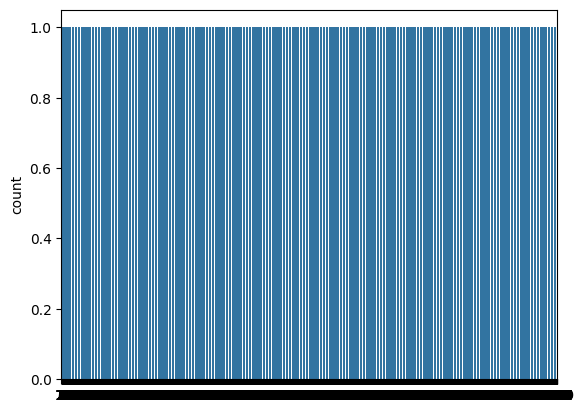

In [ ]:
# Visualize the distribution of feedback
sns.countplot(alexa_df['feedback'], label='Count')

<Axes: ylabel='count'>

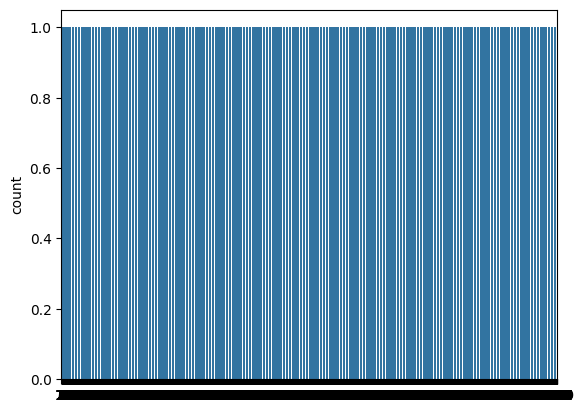

In [ ]:
# Visualize the distribution of ratings
sns.countplot(alexa_df['rating'], label='Count')

<Axes: xlabel='count', ylabel='variation'>

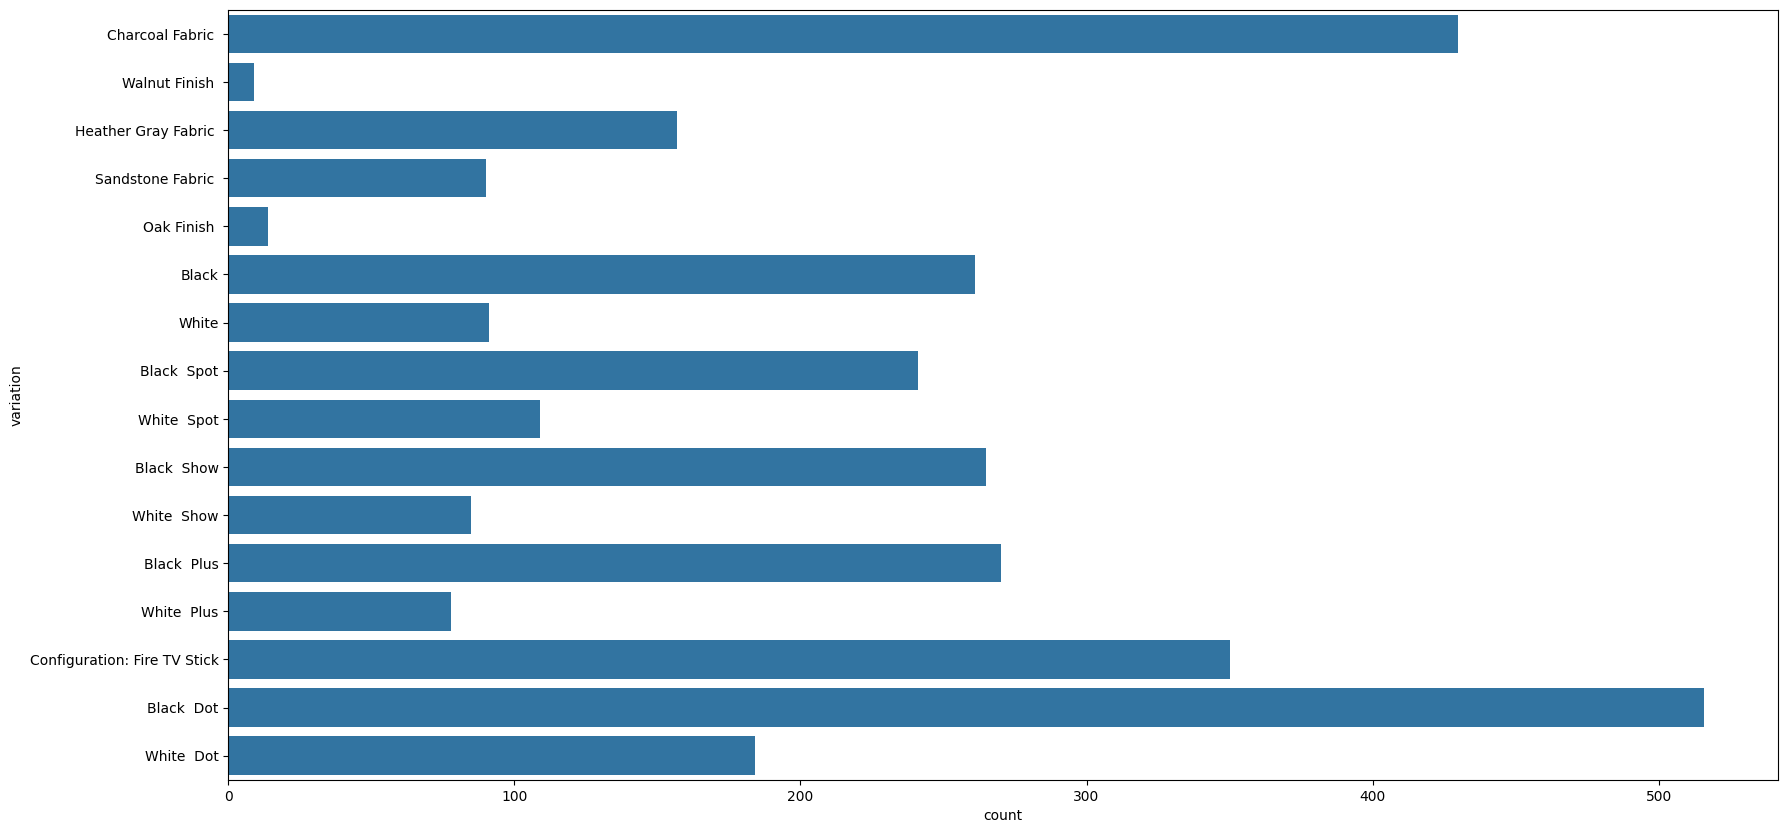

In [ ]:
# Visualize the distribution of variation
plt.figure(figsize=(20, 10))
sns.countplot(alexa_df['variation'], label='Count')

/tmp/ipykernel_45272/3600321335.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='variation', y='rating', data=alexa_df, palette='deep')


<Axes: xlabel='variation', ylabel='rating'>

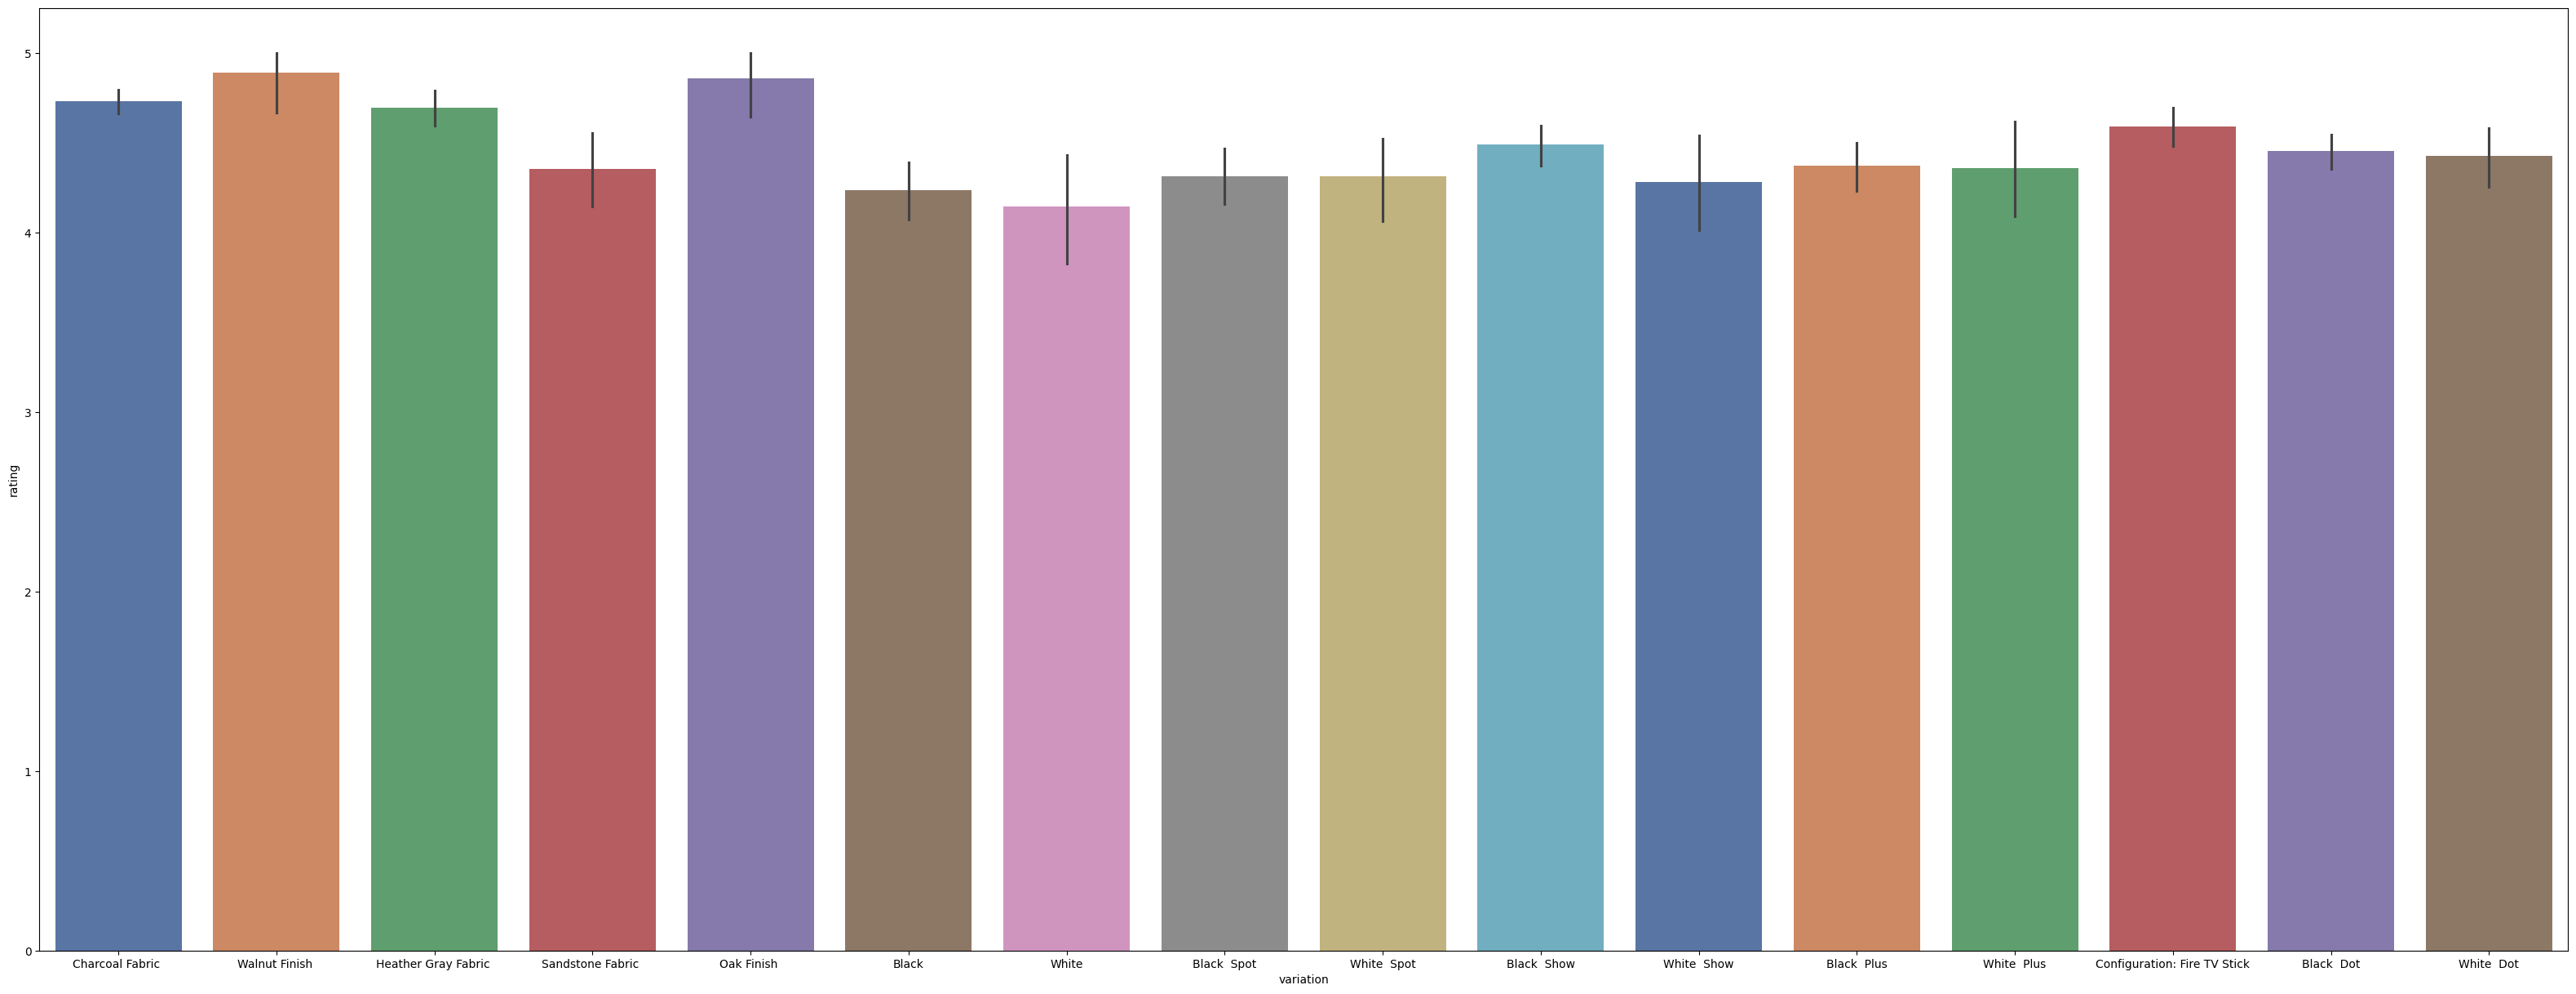

In [ ]:
# Visualize the relationship between variations and ratings
plt.figure(figsize=(40, 15))
sns.barplot(x='variation', y='rating', data=alexa_df, palette='deep')

## Drop irrelevant columns

In [ ]:
alexa_df = alexa_df.drop(['date', 'rating'], axis=1)
alexa_df

,variation,verified_reviews,feedback
0,Charcoal Fabric,Love my Echo!,1
1,Charcoal Fabric,Loved it!,1
2,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,Charcoal Fabric,Music,1
...,...,...,...
3145,Black Dot,"Perfect for kids, adults and everyone in betwe...",1
3146,Black Dot,"Listening to music, searching locations, check...",1
3147,Black Dot,"I do love these things, i have them running my...",1
3148,White Dot,Only complaint I have is that the sound qualit...,1


## One-Hot Encoding

In [ ]:
# Perform one-hot encoding on the 'variation' column
variation_dummies = pd.get_dummies(alexa_df['variation'])
alexa_df = pd.concat([alexa_df, variation_dummies], axis=1)
alexa_df = alexa_df.drop(['variation'], axis=1)
alexa_df

,verified_reviews,feedback,Black,Black Dot,Black Plus,Black Show,Black Spot,Charcoal Fabric,Configuration: Fire TV Stick,Heather Gray Fabric,Oak Finish,Sandstone Fabric,Walnut Finish,White,White Dot,White Plus,White Show,White Spot
0,Love my Echo!,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,Loved it!,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,"Sometimes while playing a game, you can answer...",1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,I have had a lot of fun with this thing. My 4 ...,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,Music,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,"Perfect for kids, adults and everyone in betwe...",1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3146,"Listening to music, searching locations, check...",1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3147,"I do love these things, i have them running my...",1,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3148,Only complaint I have is that the sound qualit...,1,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


## Tokenization using CountVectorizer

In [ ]:
# Tokenize the 'verified_reviews' column using CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Fill any NaN values in verified_reviews with empty string
alexa_df['verified_reviews'] = alexa_df['verified_reviews'].fillna('')

vectorizer = CountVectorizer()
alexa_reviews = vectorizer.fit_transform(alexa_df['verified_reviews'])

# Combine tokenized reviews with the main dataframe
alexa_reviews_df = pd.DataFrame(alexa_reviews.toarray())
alexa_df = alexa_df.drop(['verified_reviews'], axis=1)
alexa_df = pd.concat([alexa_df, alexa_reviews_df], axis=1)
alexa_df

,feedback,Black,Black Dot,Black Plus,Black Show,Black Spot,Charcoal Fabric,Configuration: Fire TV Stick,Heather Gray Fabric,Oak Finish,...,4034,4035,4036,4037,4038,4039,4040,4041,4042,4043
0,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,1,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,1,False,False,False,False,False,True,False,False,False,...,0,1,0,0,0,0,0,0,0,0
4,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,1,False,True,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3146,1,False,True,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3147,1,False,True,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3148,1,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


## Prepare data for modeling

In [ ]:
# Split the data into features (X) and target (y)
X = alexa_df.drop(['feedback'], axis=1)
Y = alexa_df['feedback']

print(X.shape, Y.shape)

(3150, 4060) (3150,)


## Train and Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y,
                                                      test_size=0.20,
                                                      random_state=5)

print(X.shape, Y.shape)
print(X_train.shape, y_train.shape, X_test.shape)

(3150, 4060) (3150,)
(2520, 4060) (2520,) (630, 4060)


## Build the Model

In [ ]:
# Model
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(units=400, activation='relu',
                                 input_shape=(X_train.shape[1], )))
model.add(tf.keras.layers.Dense(units=200, activation='relu'))
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 400)            │     1,624,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,704,801 (6.50 MB)

 Trainable params: 1,704,801 (6.50 MB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

In [ ]:
model.compile(optimizer='Adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Train the Model

In [ ]:
# Convert boolean columns to numerical
X_train = X_train.astype(float)
y_train = y_train.astype(float)

# Now fit the model
epochs_hist = model.fit(X_train, y_train, epochs=10)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9147 - loss: 0.2882
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9635 - loss: 0.0905
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9889 - loss: 0.0404
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9937 - loss: 0.0206
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9940 - loss: 0.0172
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9933 - loss: 0.0166
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9940 - loss: 0.0159
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9940 - loss: 0.0161
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9948 - loss: 0.0154
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9940 - loss: 0.0147


## Evaluate Model - Training set

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


<Axes: >

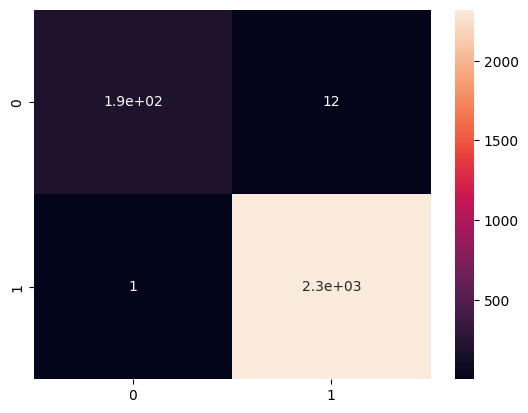

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_train = model.predict(X_train)
y_pred_train = (y_pred_train > 0.5)

cm = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm, annot=True)

## Evaluate Model - Test set

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


<Axes: >

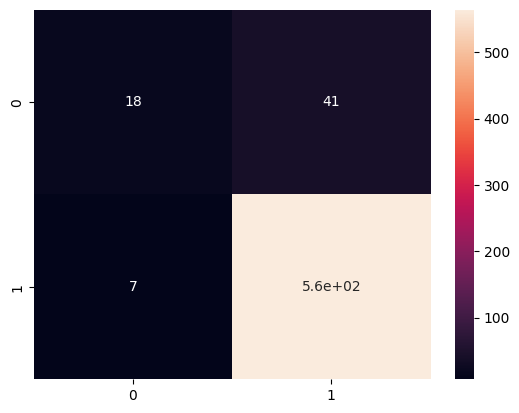

In [ ]:
# Convert boolean columns in X_test to numerical
X_test = X_test.astype(float)

# Now predict
y_pred_test = model.predict(X_test)
y_pred_test = (y_pred_test > 0.5)

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True)

## Classification Report

In [ ]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.72      0.31      0.43        59
           1       0.93      0.99      0.96       571

    accuracy                           0.92       630
   macro avg       0.83      0.65      0.69       630
weighted avg       0.91      0.92      0.91       630



## Training History Keys

In [ ]:
epochs_hist.history.keys()

dict_keys(['accuracy', 'loss'])

## Plot Model Loss Progress

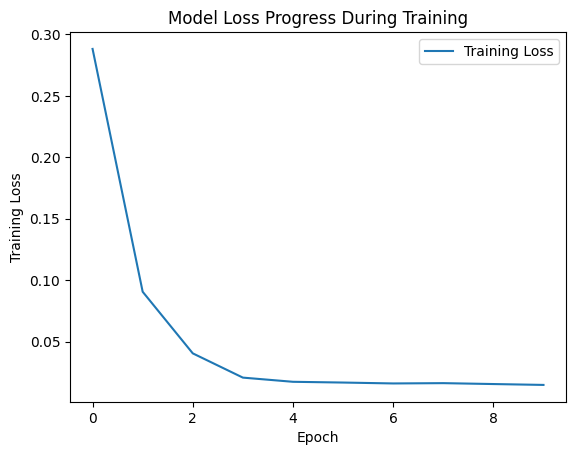

In [ ]:
plt.plot(epochs_hist.history['loss'])
plt.title('Model Loss Progress During Training')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend(['Training Loss'])

## Plot Model Accuracy Progress

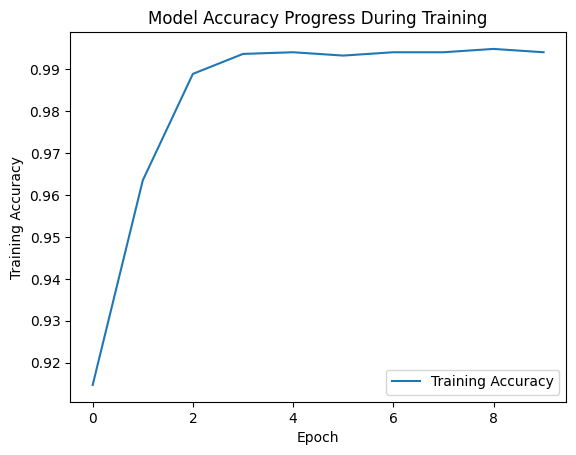

In [ ]:

plt.plot(epochs_hist.history['accuracy'])
plt.title('Model Accuracy Progress During Training')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.legend(['Training Accuracy'])

## Compare training and testing accuracy

In [ ]:
# Task 8: Analyze Model Performance
train_accuracy = model.score(X_train, y_train) \
    if hasattr(model, 'score') else \
    model.evaluate(X_train, y_train.astype(float))[1]

test_accuracy = model.evaluate(X_test, y_test.astype(float))[1]

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9948 - loss: 0.0128
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9238 - loss: 0.5369
Training Accuracy: 0.9948412775993347
Testing Accuracy: 0.9238095283508301


## Feature Importance using Random Forest

Text(0.5, 23.52222222222222, 'Predicted label')

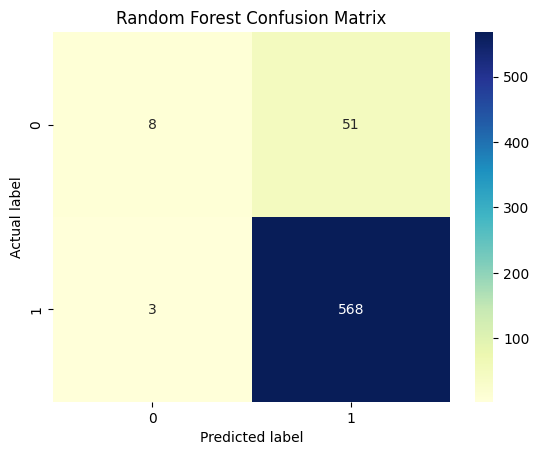

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define and train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Convert all column names to strings
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)


rf_model.fit(X_train, y_train)

# Generate predictions
rf_pred = rf_model.predict(X_test)

# Confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(rf_cm, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

## Classification Report for Random Forest

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.73      0.14      0.23        59
           1       0.92      0.99      0.95       571

    accuracy                           0.91       630
   macro avg       0.82      0.57      0.59       630
weighted avg       0.90      0.91      0.89       630



## Visualize Feature Importance

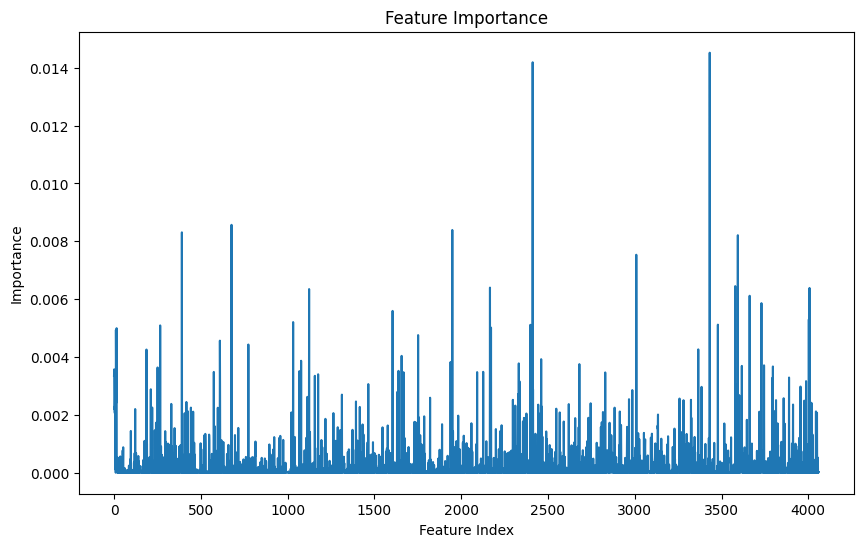

In [ ]:
# Visualize feature importance
feature_importances = rf_model.feature_importances_
plt.figure(figsize=(10, 6))
plt.plot(feature_importances)
plt.title('Feature Importance')
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.show()

## Make predictions on new data

In [ ]:
# Create a function to predict sentiment of a new review
def predict_sentiment(new_review):
    # Vectorize the new review
    new_review_vectorized = vectorizer.transform([new_review]).toarray()

    # Convert to DataFrame with string column names
    new_review_df = pd.DataFrame(new_review_vectorized)
    new_review_df.columns = new_review_df.columns.astype(str)

    # Add missing columns with zeros to match training features
    for col in X_train.columns:
        if col not in new_review_df.columns:
            new_review_df[col] = 0

    # Reorder columns to match training data
    new_review_df = new_review_df[X_train.columns]

    prediction = rf_model.predict(new_review_df)
    if prediction[0] == 1:
        return "Positive"
    else:
        return "Negative"

# Example usage
new_review = "I love my Alexa device! It's so helpful."
predicted_sentiment = predict_sentiment(new_review)
print(f"The sentiment of the new review is: {predicted_sentiment}")

The sentiment of the new review is: Positive
